# Week 3 Final Project
– Sales Data Analysis
**Complete Pipeline:**
Load → Clean → Explore → Visualize → Insights
This notebook combines Python fundamentals, NumPy/Pandas, Data Cleaning, and EDA from Week 3 into one end-to-end analysis.

## 1. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('messy_sales_data.csv') 
print(df.shape)
df.head(15)

(14, 8)


,order_id,customer_name,city,product,category,quantity,price,order_date
0,1,Ali,lahore,Laptop,Electronics,1.0,80000.0,10/01/2025
1,2,sara,Karachi,Mouse,Accessories,2.0,1500.0,12/01/2025
2,3,Usman,LAHORE,Keyboard,accessories,1.0,3000.0,15-01-2025
3,4,Ayesha,Islamabad,Monitor,Electronics,NaN,20000.0,2025-01-18
4,5,Bilal,Lahore,Laptop,Electronics,1.0,80000.0,20/01/2025
5,6,Sara,Karachi,Keyboard,Accessories,1.0,3000.0,05/02/2025
6,6,Sara,Karachi,Keyboard,Accessories,1.0,3000.0,05/02/2025
7,7,Usman,Lahore,Mouse,Accessories,3.0,1500.0,10/02/2025
8,8,Ali,lahore,Monitor,Electronics,2.0,20000.0,15/02/2025
9,9,Hina,Multan,Laptop,electronics,1.0,80000.0,18/02/2025


## 2. Data Cleaning

In [3]:
def clean_sales_data(raw_df):
    df = raw_df.copy()
    df['quantity'] = df['quantity'].fillna(1)
    df['price'] = df['price'].fillna(df.groupby('product')['price'].transform('mean'))
    df['city'] = df['city'].fillna('Unknown')
    df = df.drop_duplicates()
    df['city'] = df['city'].str.strip().str.title()
    df['category'] = df['category'].str.strip().str.title()
    df['customer_name'] = df['customer_name'].str.strip().str.title()
    df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
    df['quantity'] = df['quantity'].astype(int)
    df['price'] = df['price'].astype(float)
    avg_prices = df[df['price'] > 0].groupby('product')['price'].mean()
    df.loc[df['price'] < 0, 'price'] = df.loc[df['price'] < 0, 'product'].map(avg_prices)
    median_qty = df['quantity'].median()
    df.loc[df['quantity'] > 50, 'quantity'] = median_qty
    df['total_amount'] = df['price'] * df['quantity']
    df['order_month'] = df['order_date'].dt.month
    return df

In [4]:
cleaned_df = clean_sales_data(df)
cleaned_df.head()

,order_id,customer_name,city,product,category,quantity,price,order_date,total_amount,order_month
0,1,Ali,Lahore,Laptop,Electronics,1,80000.0,2025-01-10,80000.0,1
1,2,Sara,Karachi,Mouse,Accessories,2,1500.0,2025-01-12,3000.0,1
2,3,Usman,Lahore,Keyboard,Accessories,1,3000.0,2025-01-15,3000.0,1
3,4,Ayesha,Islamabad,Monitor,Electronics,1,20000.0,2025-01-18,20000.0,1
4,5,Bilal,Lahore,Laptop,Electronics,1,80000.0,2025-01-20,80000.0,1


In [5]:
cleaned_df.to_csv('cleaned_sales_data.csv', index=False)
print("Cleaned dataset saved successfully!")
print(cleaned_df.shape)

Cleaned dataset saved successfully!
(13, 10)


In [6]:
cleaned_df.describe()

,order_id,quantity,price,order_date,total_amount,order_month
count,13.00000,13.000000,13.000000,13,13.000000,13.000000
mean,7.00000,1.384615,28777.777778,2025-02-06 03:41:32.307692288,30726.495726,1.846154
min,1.00000,1.000000,833.333333,2025-01-10 00:00:00,1277.777778,1.000000
25%,4.00000,1.000000,1500.000000,2025-01-18 00:00:00,3000.000000,1.000000
50%,7.00000,1.000000,3000.000000,2025-02-10 00:00:00,4500.000000,2.000000
75%,10.00000,2.000000,80000.000000,2025-02-20 00:00:00,80000.000000,2.000000
max,13.00000,3.000000,80000.000000,2025-03-05 00:00:00,80000.000000,3.000000
std,3.89444,0.650444,36133.710877,NaN,35808.672691,0.800641


In [7]:
print("Correlation:\n", cleaned_df[['price', 'quantity', 'total_amount']].corr())
print(cleaned_df.groupby('category')['total_amount'].sum())

Correlation:
                  price  quantity  total_amount
price         1.000000 -0.420357      0.988365
quantity     -0.420357  1.000000     -0.357662
total_amount  0.988365 -0.357662      1.000000
category
Accessories     19444.444444
Electronics    380000.000000
Name: total_amount, dtype: float64


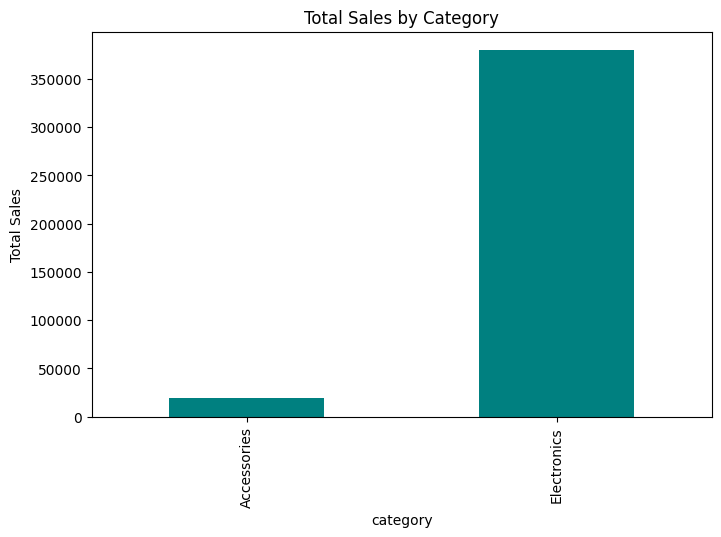

In [8]:
plt.figure(figsize=(8,5))
cleaned_df.groupby('category')['total_amount'].sum().plot(kind='bar', color='teal')
plt.title('Total Sales by Category')
plt.ylabel('Total Sales')
plt.show()

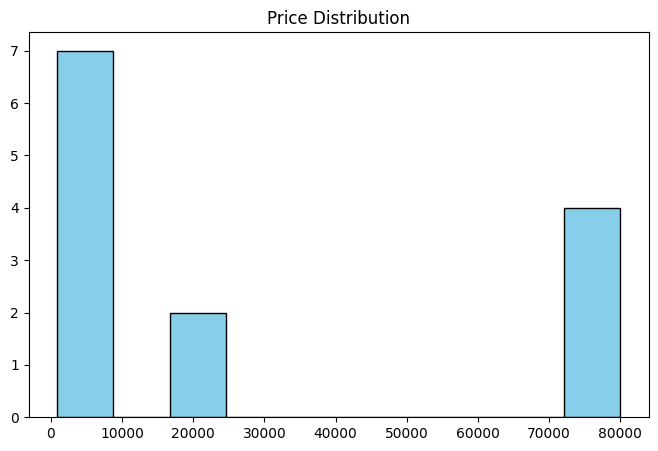

In [9]:
plt.figure(figsize=(8,5))
plt.hist(cleaned_df['price'], bins=10, color='skyblue', edgecolor='black')
plt.title('Price Distribution')
plt.show()

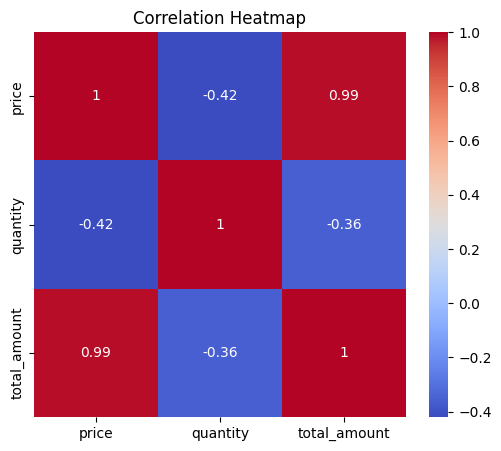

In [10]:
plt.figure(figsize=(6,5))
sns.heatmap(cleaned_df[['price','quantity','total_amount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()